В этом блокноте представлено сравнение архитектур моделей, точности и тд.

In [1]:
!source .venv/bin/activate && python --version && pip --version

Python 3.13.5
pip 25.1.1 from /home/vladimir/Документы/Проекты/Личные/defects_detection/.venv/lib/python3.13/site-packages/pip (python 3.13)


In [6]:
import logging
import warnings
from io import StringIO
from pathlib import Path

from ultralytics import YOLO

proj = Path(".").resolve()


def first_lines_model_info(model, n=5):
    buf = StringIO()
    log = logging.getLogger("ultralytics")
    prev_handlers, prev_propagate = list(log.handlers), log.propagate
    log.handlers.clear()
    log.addHandler(logging.StreamHandler(buf))
    log.propagate = False
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            model.info(detailed=True, verbose=True)
    finally:
        log.handlers.clear()
        log.handlers.extend(prev_handlers)
        log.propagate = prev_propagate
    return buf.getvalue().strip().splitlines()[:n]


def print_info_head(title, weights):
    print(title)
    print("\n".join(first_lines_model_info(YOLO(str(weights)).model)))
    print()


print_info_head(
    "RGB (best.pt)",
    proj / "train_and_test_results/defects_rgb_det/defects_rgb_y26n640/weights/best.pt",
)
print_info_head(
    "RGB-D 4ch (best.pt)",
    proj / "train_and_test_results/defects_rgbd_4ch_det/defects_rgbd_y26n640/weights/best.pt",
)


RGB (best.pt)
layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d     False         432       [16, 3, 3, 3]  -0.00127     0.295        float32
    1                       model.0.bn.weight         BatchNorm2d     False          16                [16]      3.36      1.45        float32
    1                         model.0.bn.bias         BatchNorm2d     False          16                [16]    0.0313      5.35        float32
    2                             model.0.act                SiLU     False           0                  []         -         -              -

RGB-D 4ch (best.pt)
layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d     False         576       [16, 4, 3, 3]   -0.0144     0.269        fl

Можно заметить, что входы у моделей действительно отличаются. Как и кол-тво параметров (разница именно из-за первого сверточного слоя):

In [7]:
from pathlib import Path

from ultralytics import YOLO

proj = Path(".").resolve()
for title, w in (
    ("RGB", proj / "train_and_test_results/defects_rgb_det/defects_rgb_y26n640/weights/best.pt"),
    ("RGB-D 4ch", proj / "train_and_test_results/defects_rgbd_4ch_det/defects_rgbd_y26n640/weights/best.pt"),
):
    n = sum(p.numel() for p in YOLO(str(w)).model.parameters())
    print(f"{title}: {n:,}")


RGB: 2,504,190
RGB-D 4ch: 2,504,334


Далее сравнение на тестовом сплите по сохранённому прогону на сервере


Тест
  Изображений:      520
  Экземпляров (GT): 902
  Precision (Box):  0.865
  Recall (Box):     0.769
  mAP50 (Box):      0.841
  mAP50-95 (Box):   0.568


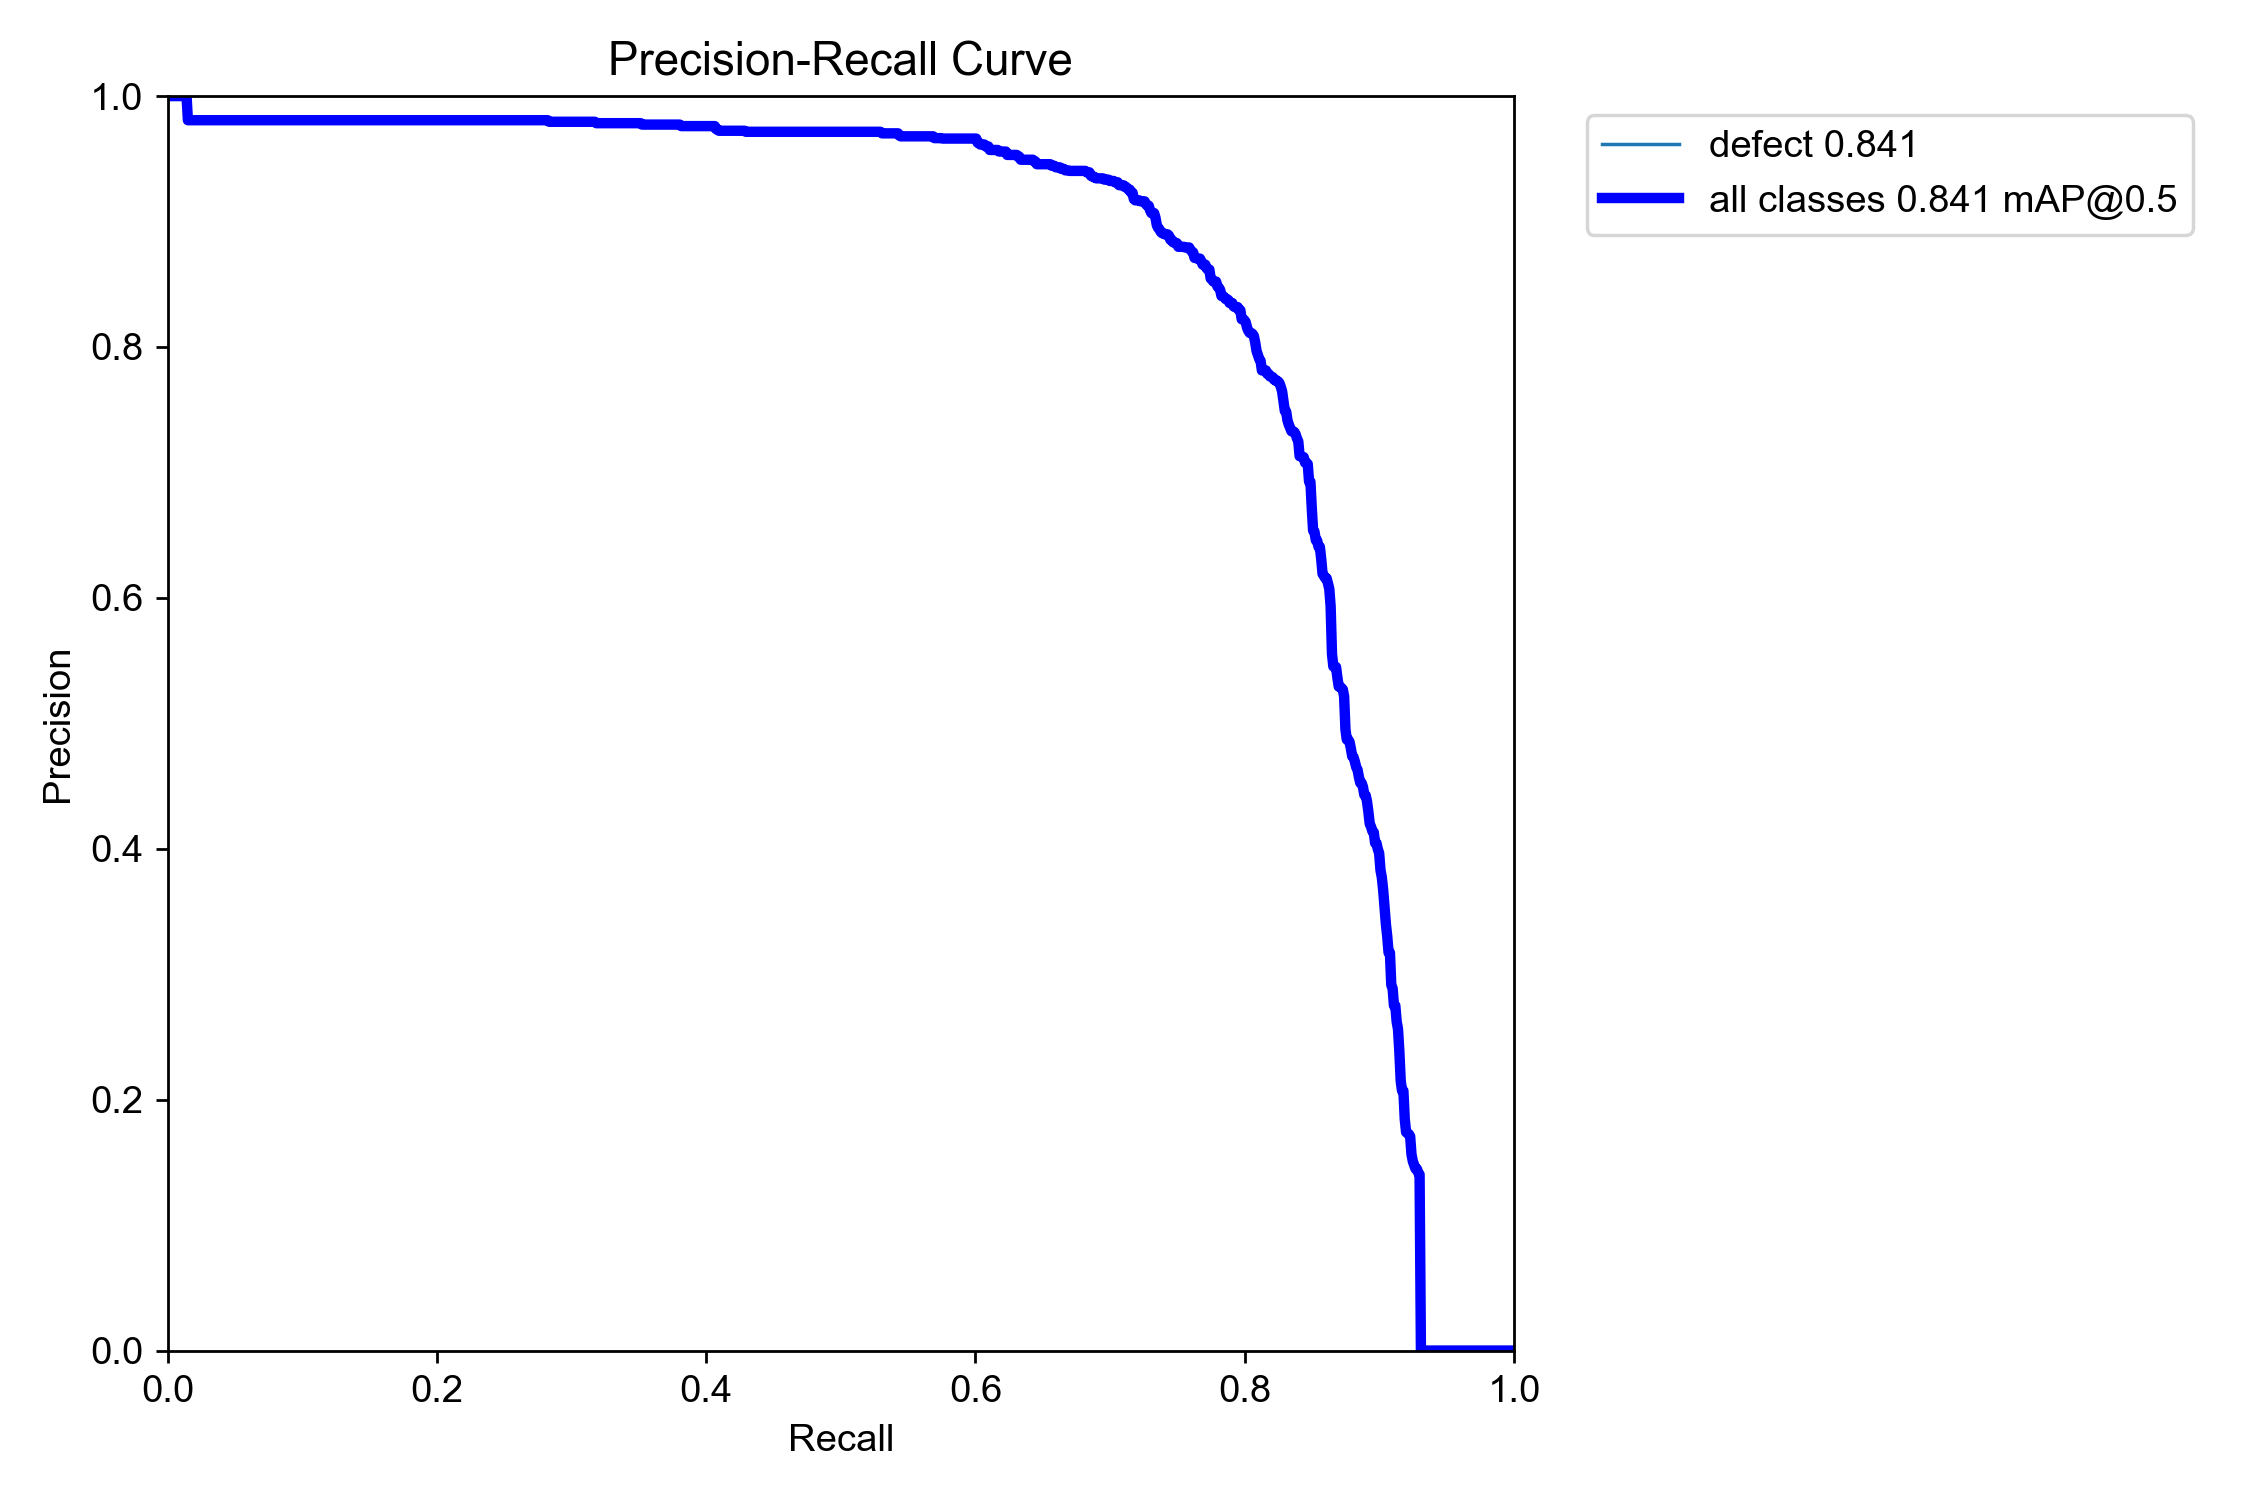

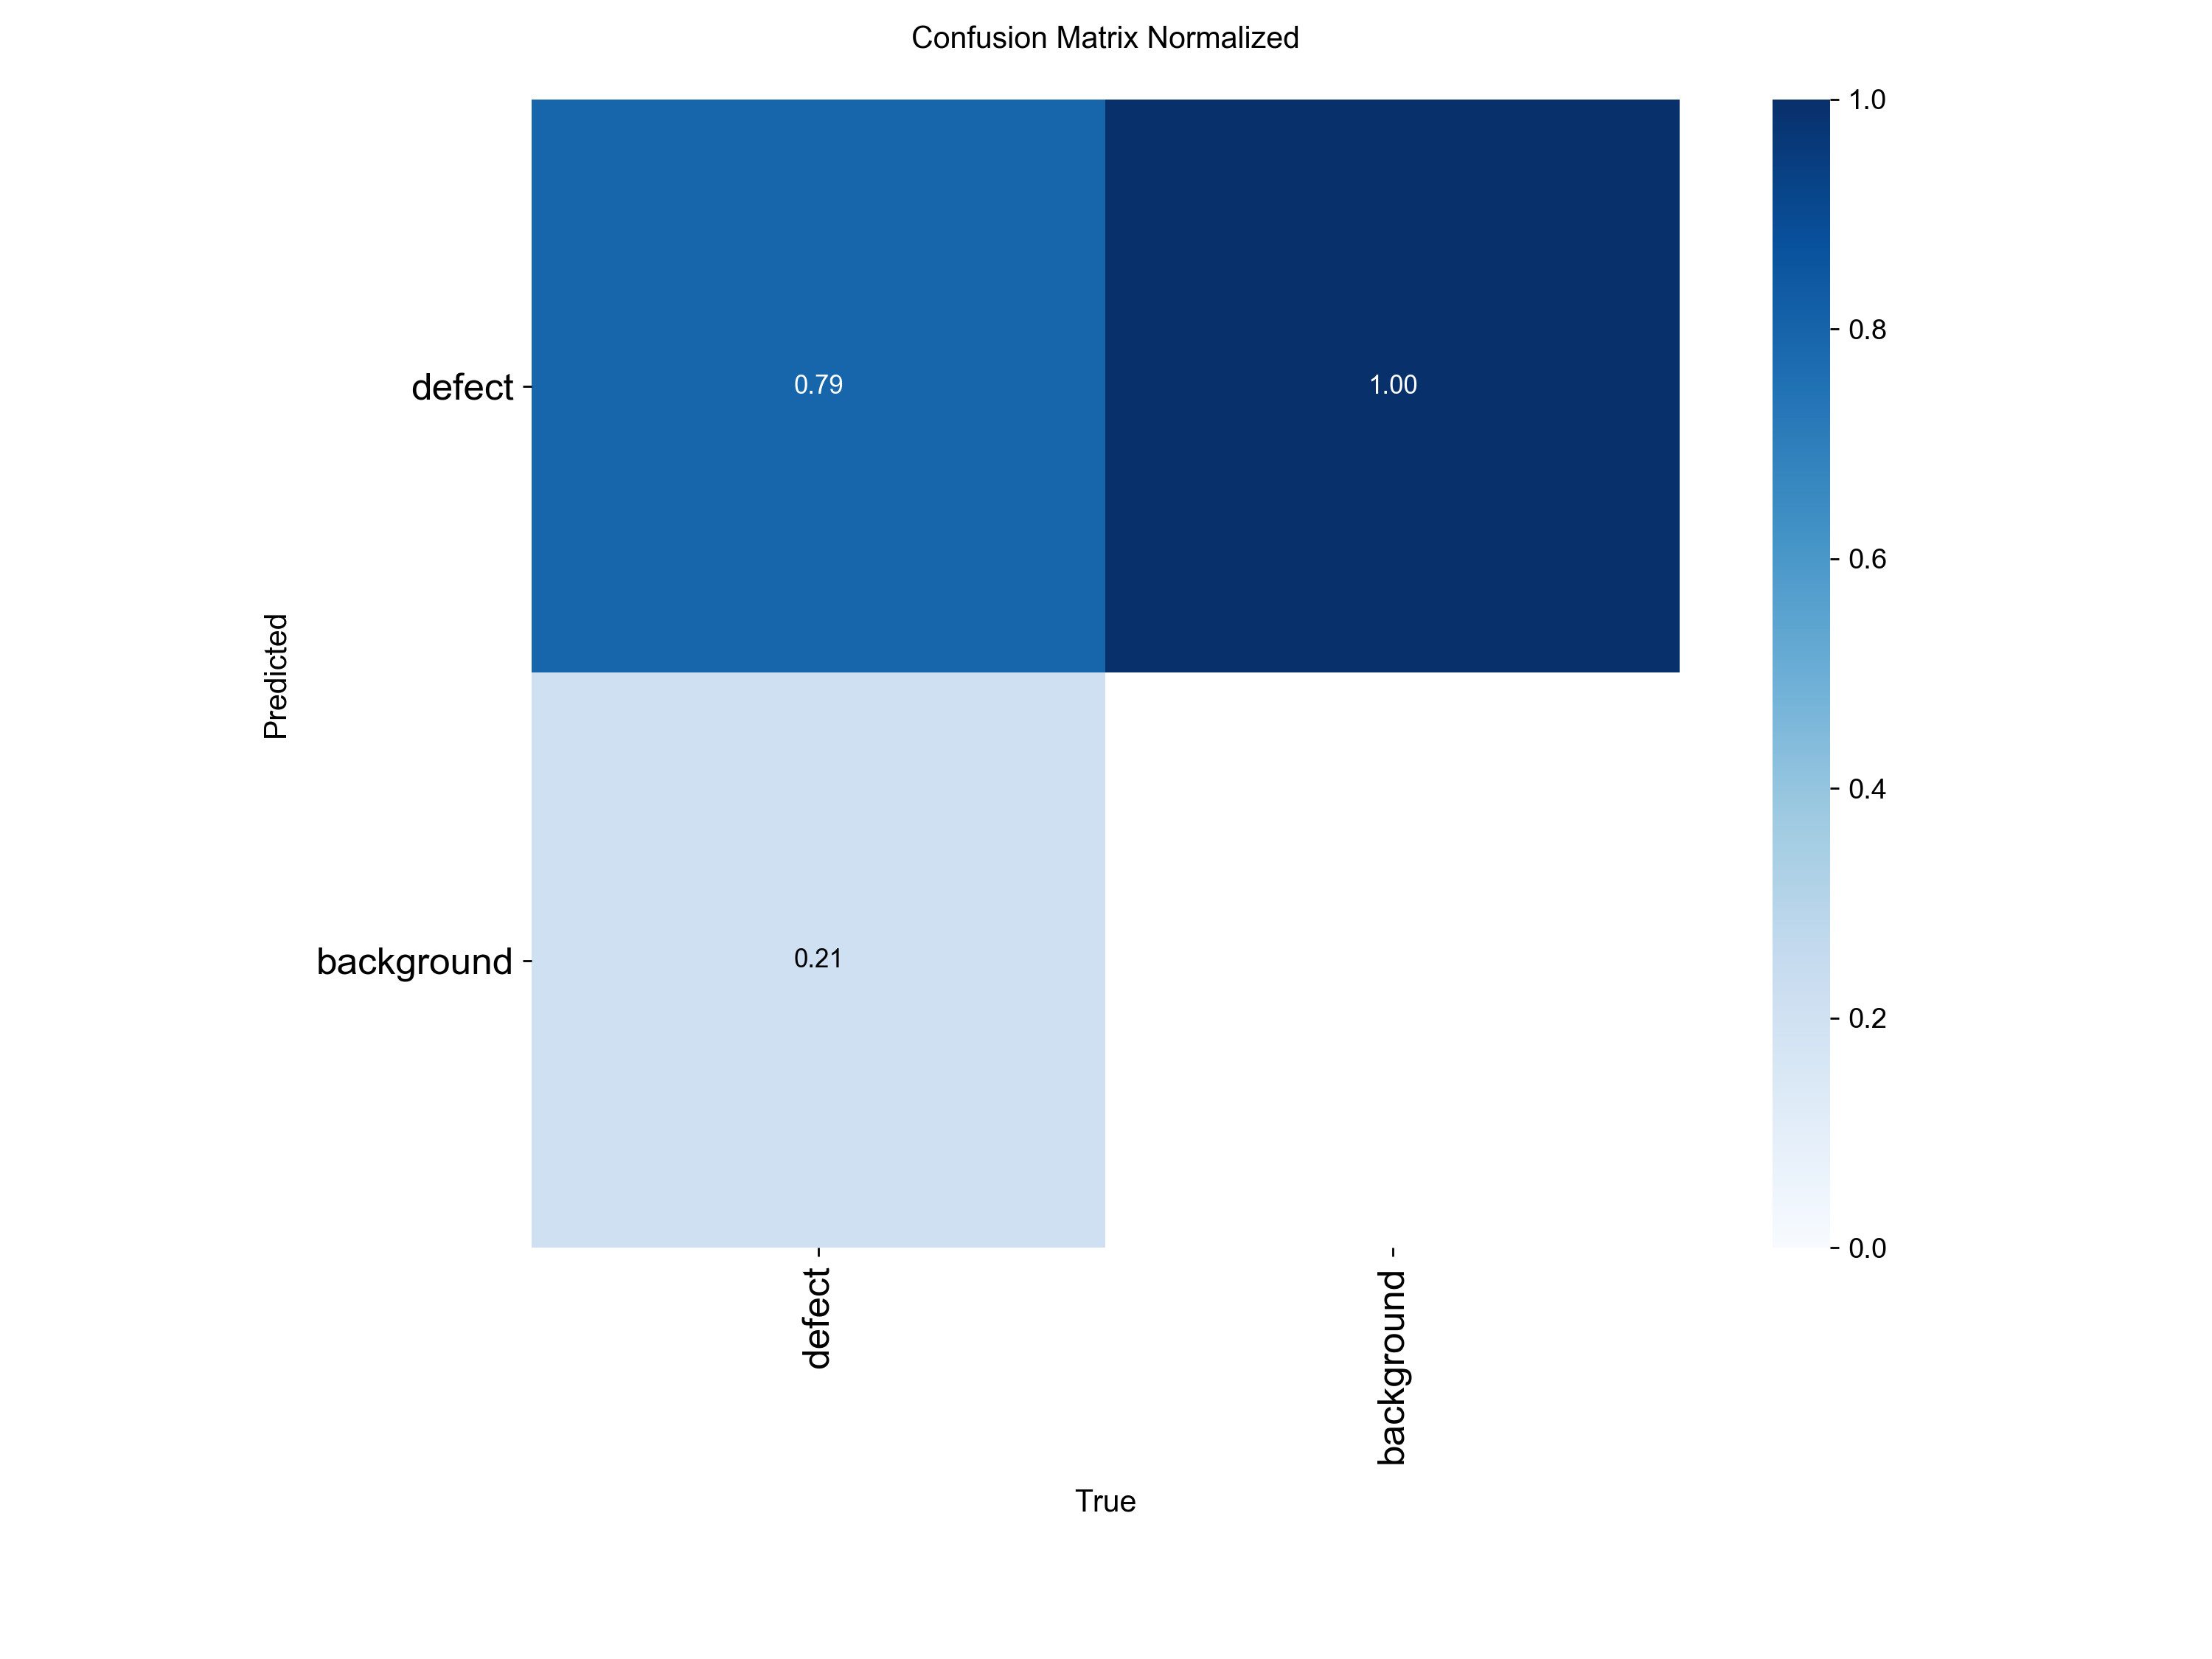

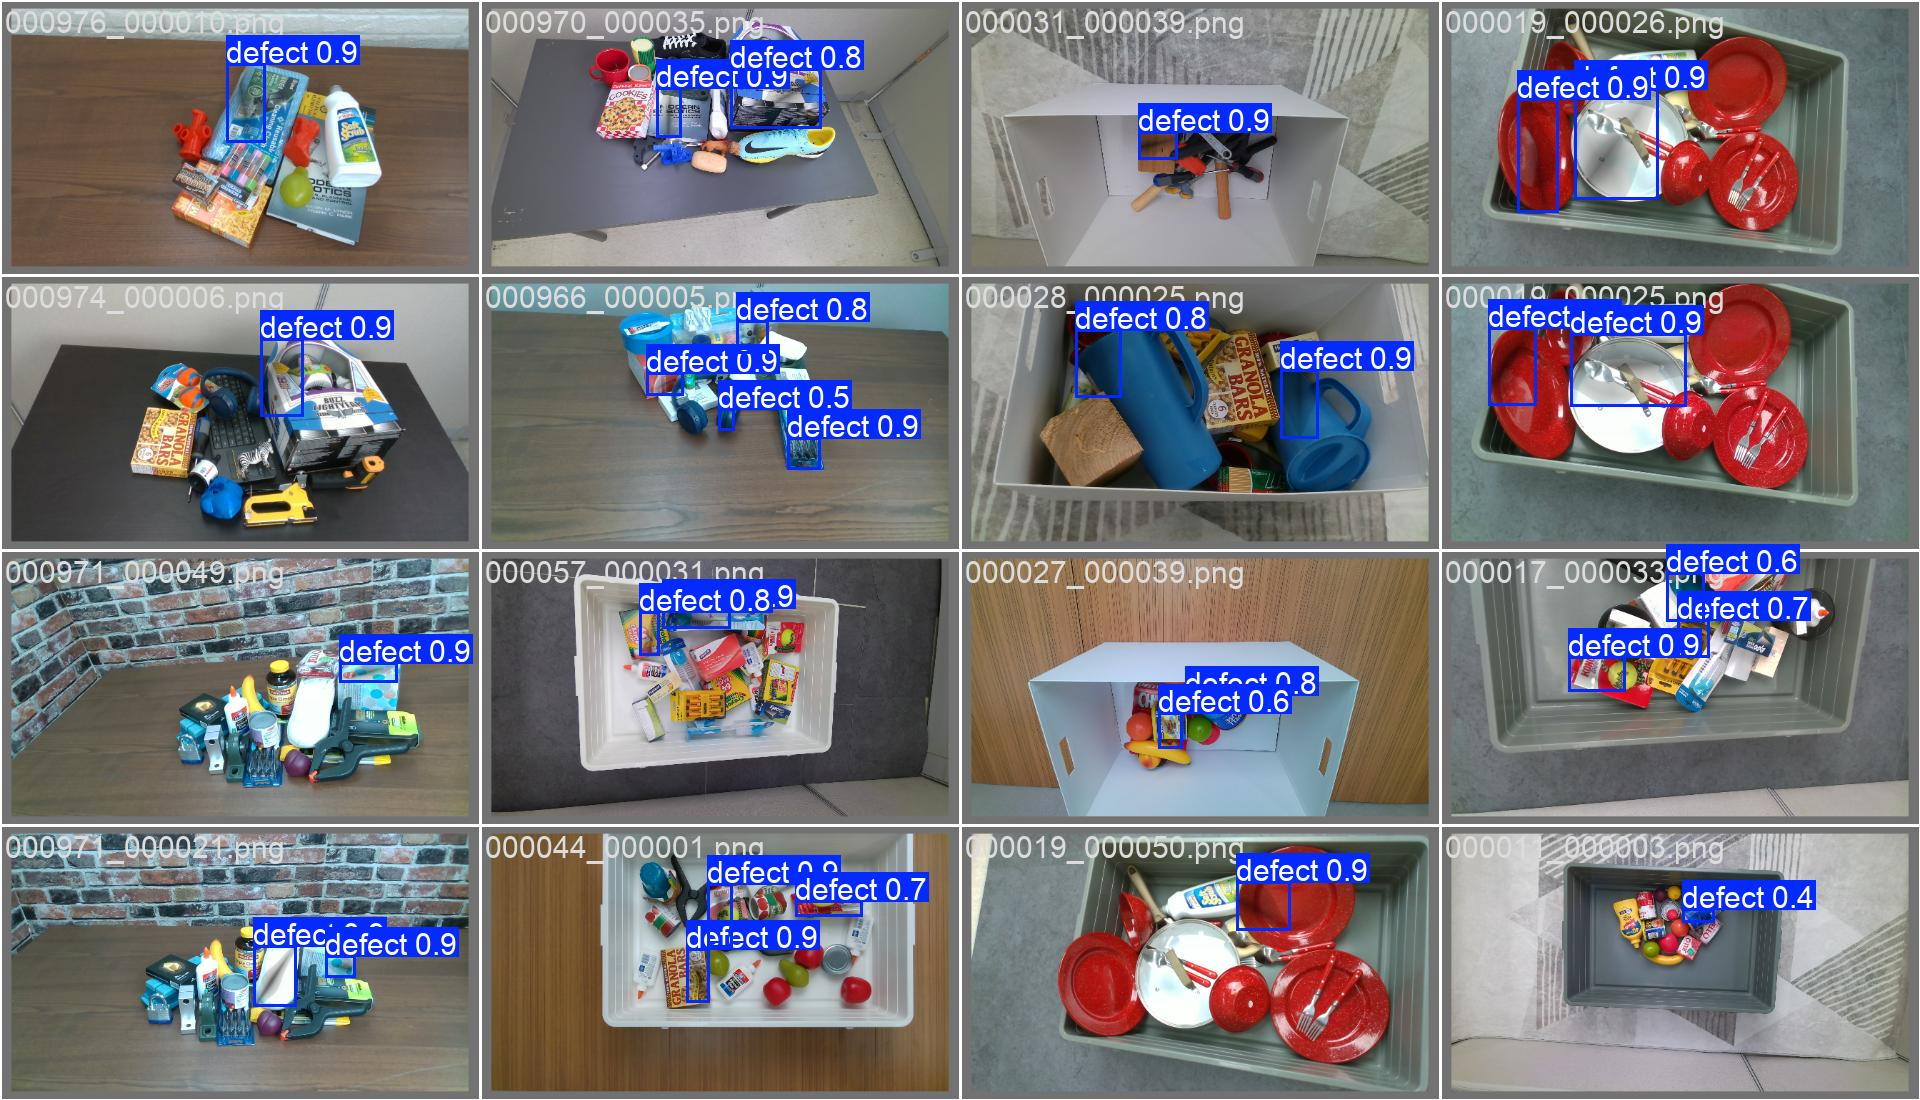

In [12]:
from pathlib import Path

from IPython.display import Image, display

proj = Path(".").resolve()
split_dir = proj / "train_and_test_results/defects_rgb_det/defects_rgb_y26n640/val_test_split"
metrics = split_dir.parent / "METRICS_train_and_test.txt"

txt = metrics.read_text(encoding="utf-8")
print(txt[txt.index("Тест") :].strip())

for fn in ("BoxPR_curve.png", "confusion_matrix_normalized.png", "val_batch0_pred.jpg"):
    display(Image(filename=str(split_dir / fn)))


Тест
  Изображений:      520
  Экземпляров (GT): 902
  Precision (Box):  0.863
  Recall (Box):     0.799
  mAP50 (Box):      0.846
  mAP50-95 (Box):   0.576


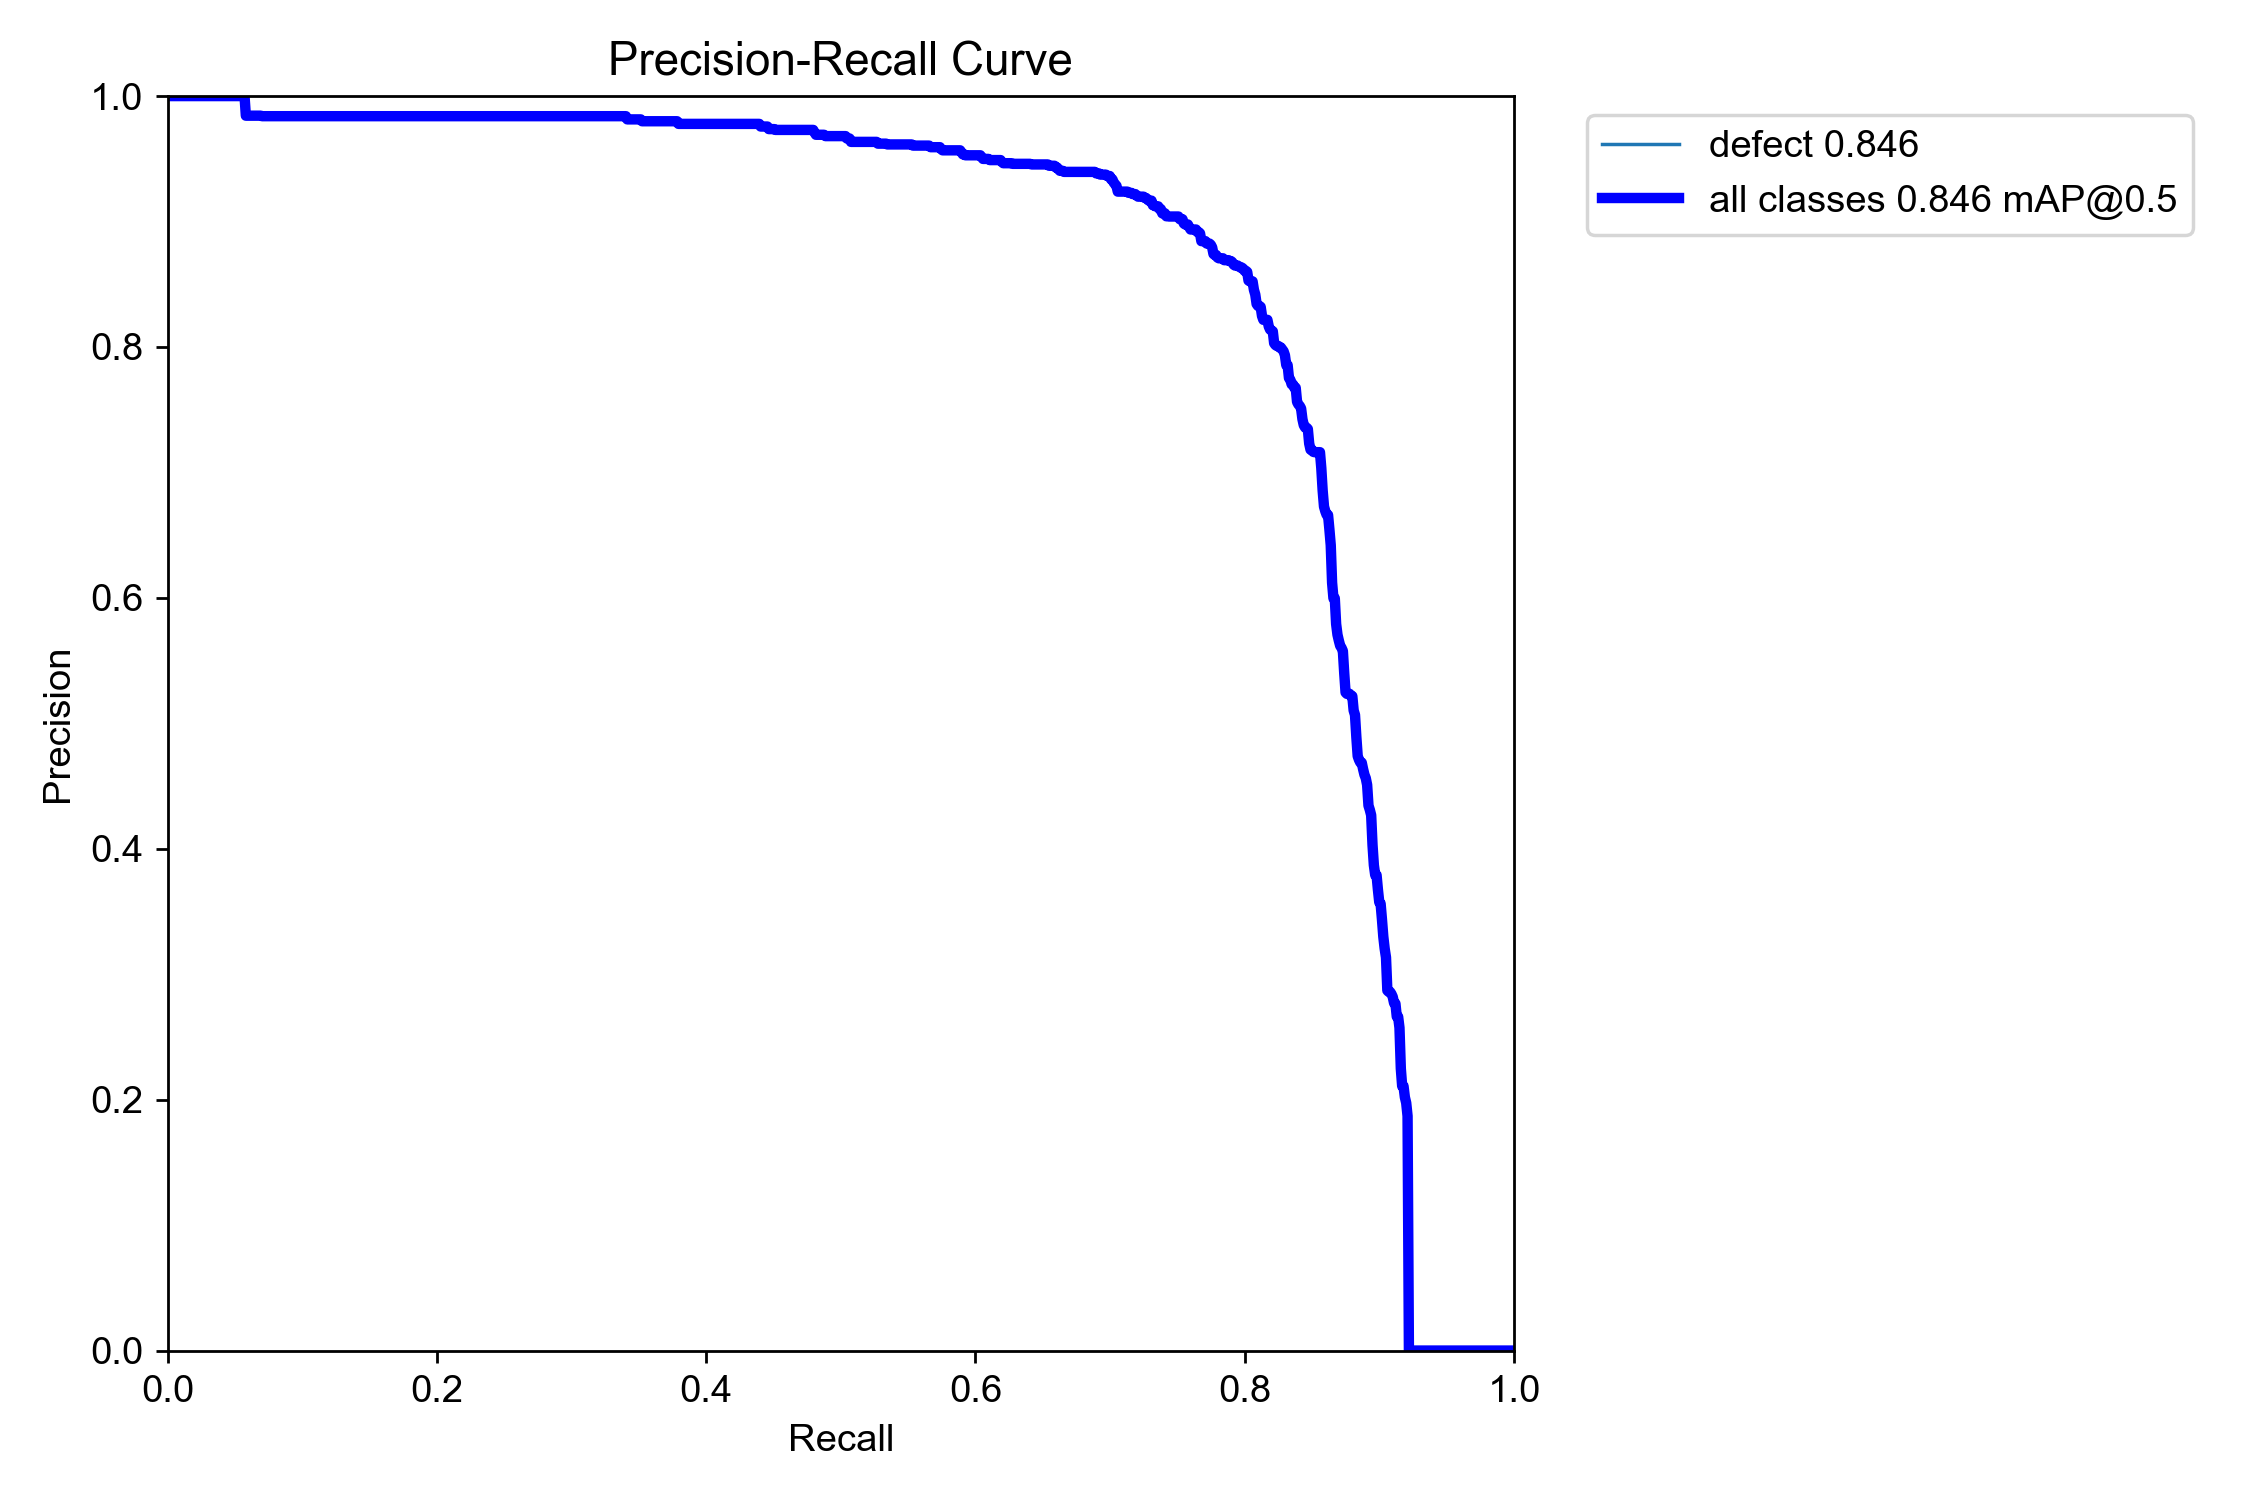

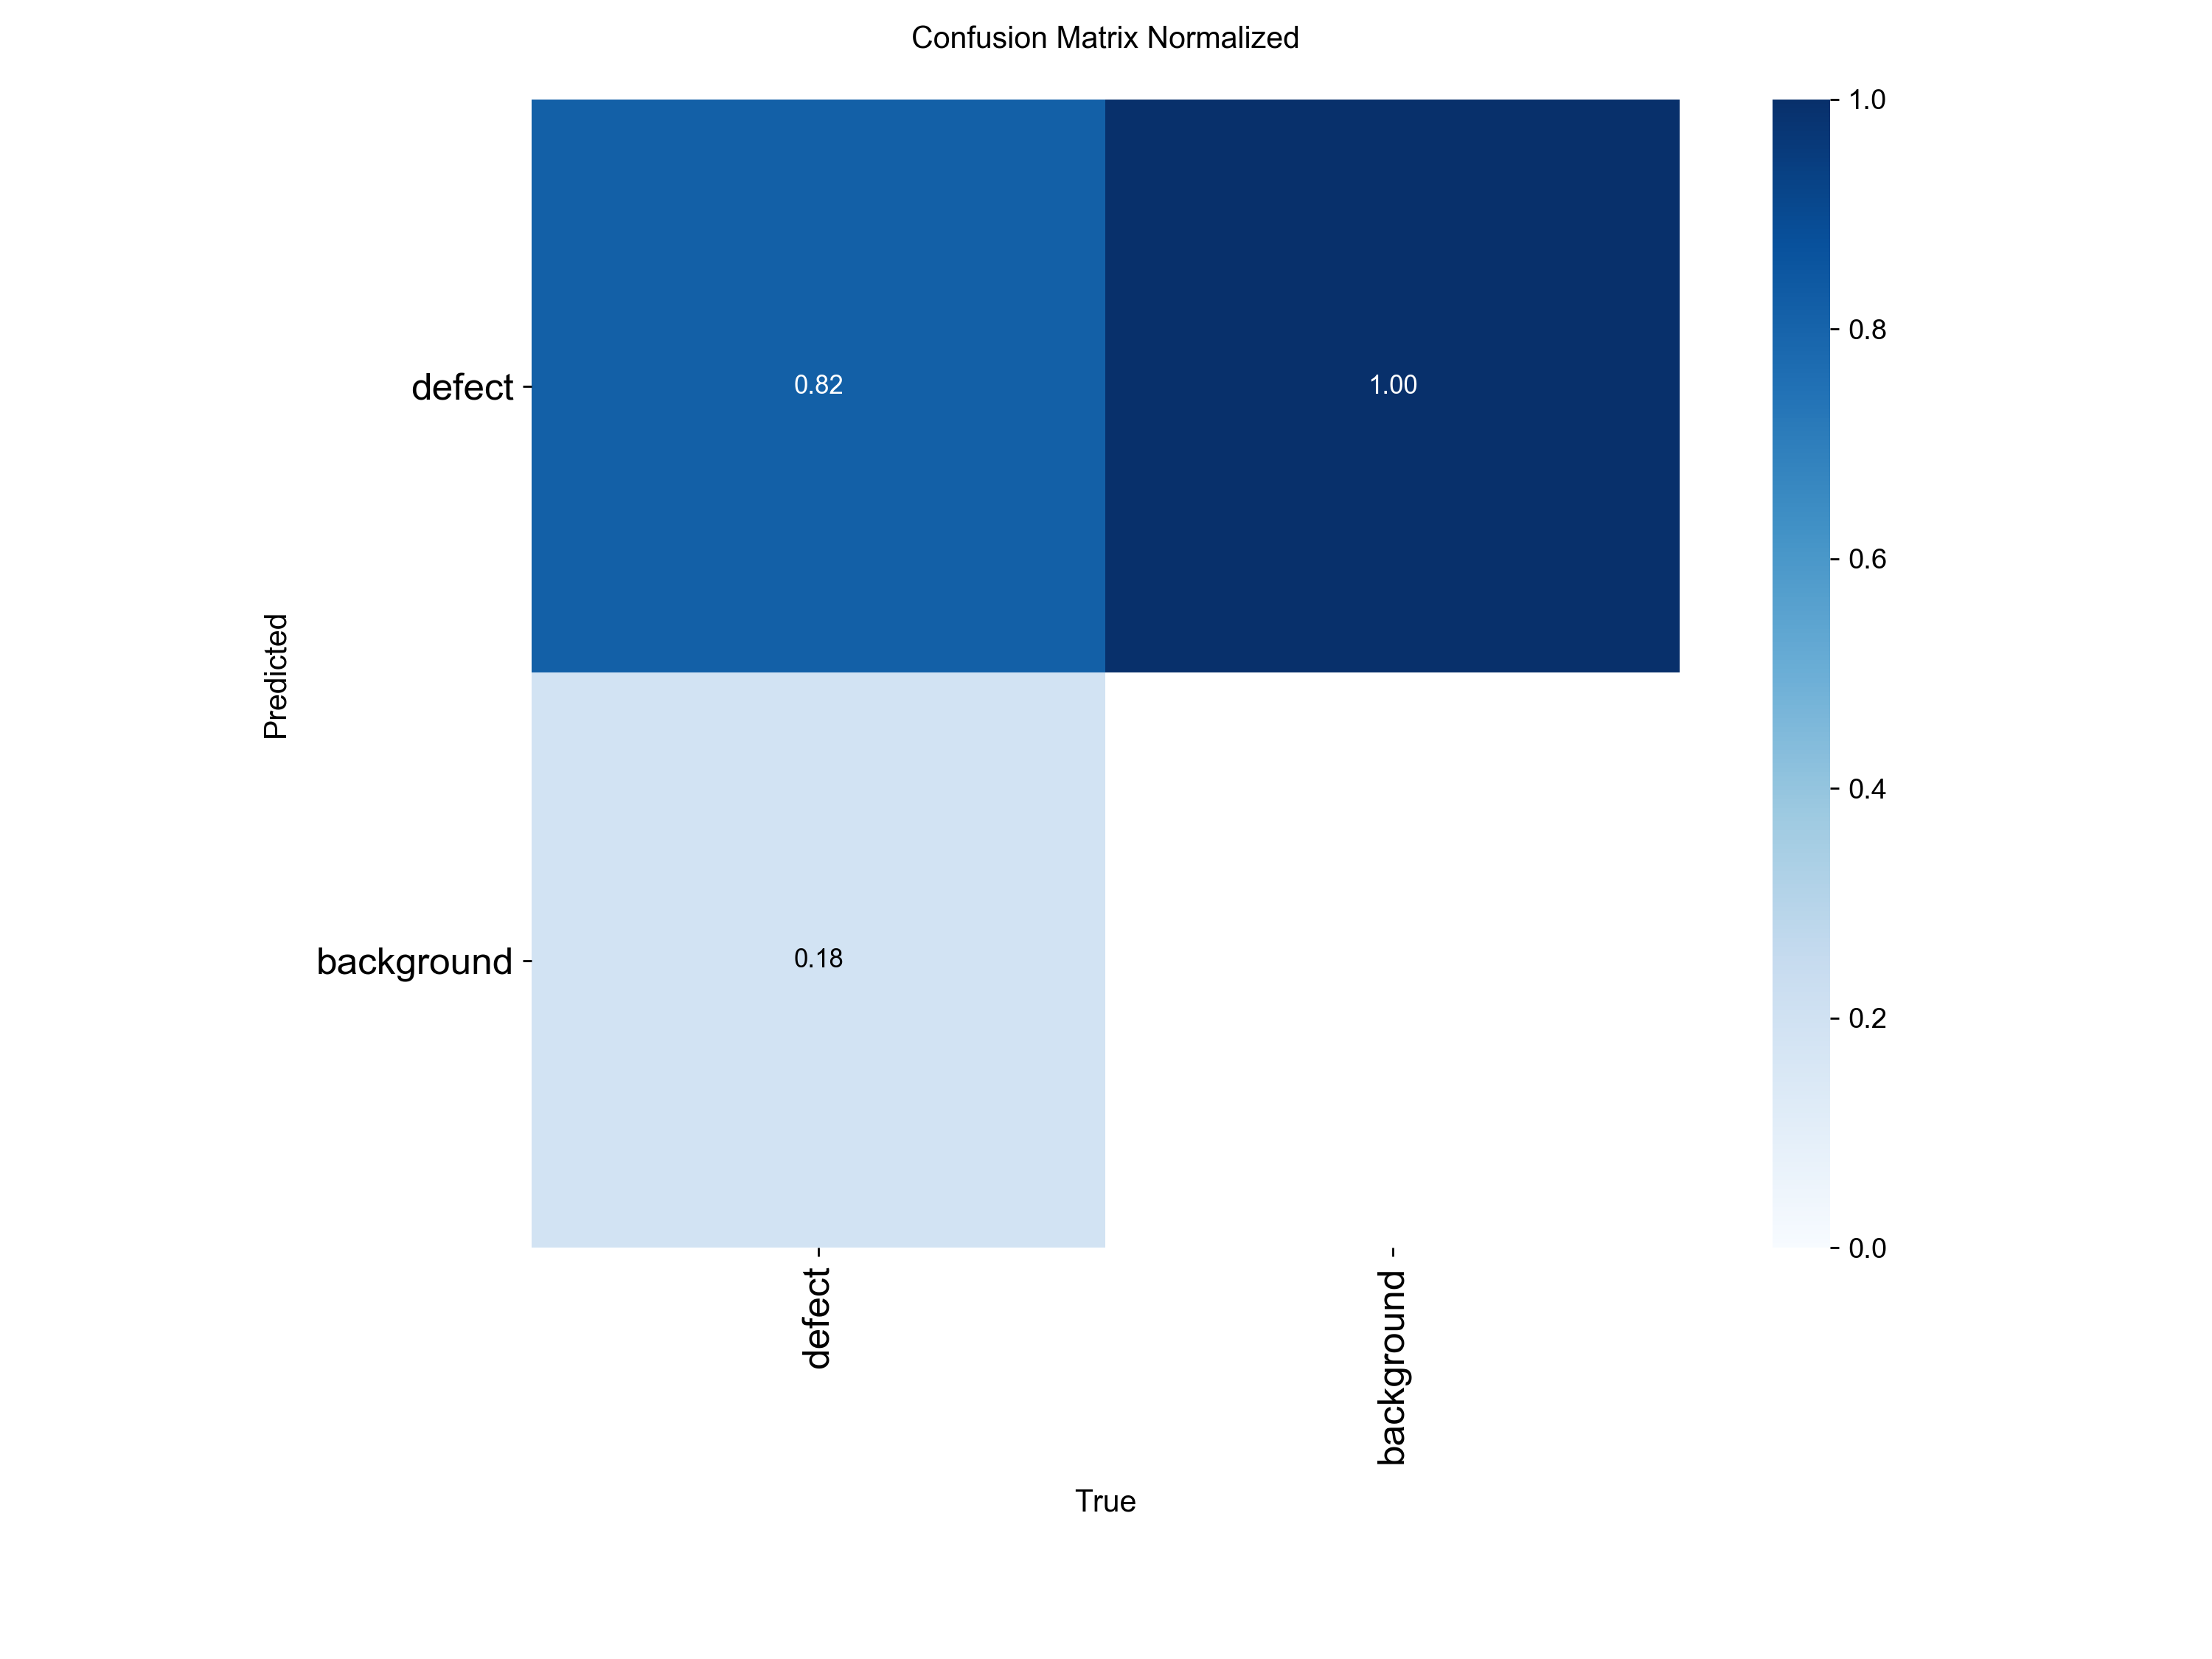

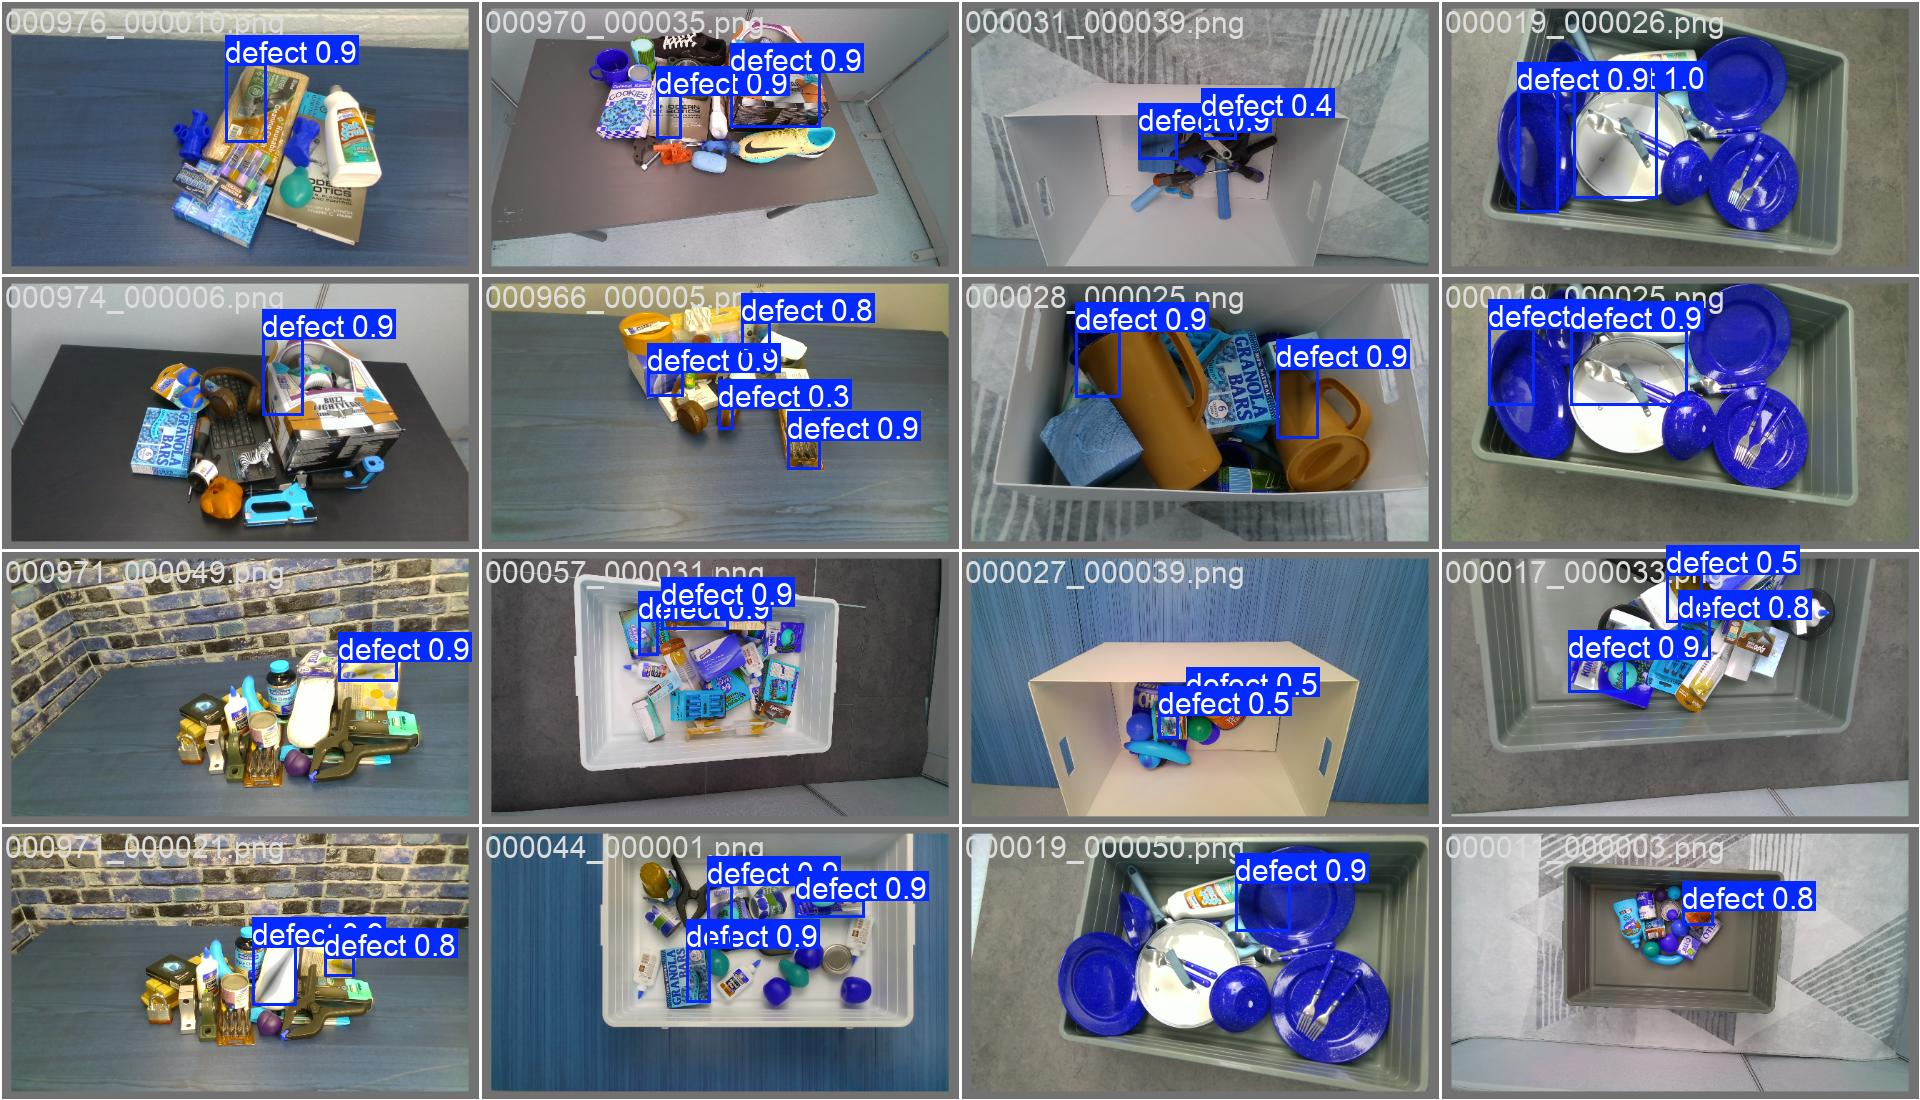

In [11]:
from pathlib import Path

from IPython.display import Image, display

proj = Path(".").resolve()
split_dir = proj / "train_and_test_results/defects_rgbd_4ch_det/defects_rgbd_y26n640/val_test_split"
metrics = split_dir.parent / "METRICS_train_and_test.txt"

txt = metrics.read_text(encoding="utf-8")
print(txt[txt.index("Тест") :].strip())

for fn in ("BoxPR_curve.png", "confusion_matrix_normalized.png", "val_batch0_pred.jpg"):
    display(Image(filename=str(split_dir / fn)))


Можно сделать вывод, что по тестовым метрикам RGB и RGB-D модели получились примерно одного уровня - явного перевеса одной архитектуры над другой нет. Это ожидаемо для текущей постановки, так как дефекты на изображения накладывались синтетически, то есть не как в реальных сценах съёмки, поэтому и данные, и выводы носят демонстрационный характер. На более реалистичных дефектах и в другом домене разница между RGB и использованием глубины могла бы проявиться сильнее.

В общем случае, если данные и условия съёмки сложные, RGB-D может дать лучшую точность за счёт дополнительной информации о геометрии сцены. В более простых сценах часто достаточно RGB


Далее дополнительно еще сравним значения F1 для каждой модели на тестовой выборке

In [8]:
from pathlib import Path

from ultralytics import YOLO

proj = Path(".").resolve()
m = YOLO(str(proj / "train_and_test_results/defects_rgb_det/defects_rgb_y26n640/weights/best.pt")).val(
    data=str("/home/vladimir/Документы/Датасеты/defects_rgbd_4ch_det/data.yaml"),
    split="test",
    verbose=True,
)
print(m.box.f1)


Ultralytics 8.4.48 🚀 Python-3.13.5 torch-2.11.0+cu130 CPU (13th Gen Intel Core i5-13420H)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.3 ms, read: 874.8±243.0 MB/s, size: 18030.1 KB)
val: Scanning /home/vladimir/Документы/Датасеты/defects_rgbd_4ch_det/test/labels... 520 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 520/520 43.8it/s 11.9s0.4s
val: New cache created: /home/vladimir/Документы/Датасеты/defects_rgbd_4ch_det/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 1.4s/it 47.6s1.2ss
                   all        520        902      0.865      0.769      0.841      0.568
Speed: 0.6ms preprocess, 31.8ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/vladimir/Документы/Проекты/Личные/defects_detection/runs/detect/val
[     0.8142]


In [10]:
import sys
from pathlib import Path

proj = Path(".").resolve()
if str(proj) not in sys.path:
    sys.path.insert(0, str(proj))
from utils.train_rgbd_4ch_yolo import apply_ultralytics_4channel_loader_patch
from ultralytics import YOLO

apply_ultralytics_4channel_loader_patch()
m = YOLO(str(proj / "train_and_test_results/defects_rgbd_4ch_det/defects_rgbd_y26n640/weights/best.pt")).val(
    data=str("/home/vladimir/Документы/Датасеты/defects_rgbd_4ch_det/data.yaml"),
    split="test",
    verbose=True,
)
print(m.box.f1)


Ultralytics 8.4.48 🚀 Python-3.13.5 torch-2.11.0+cu130 CPU (13th Gen Intel Core i5-13420H)
YOLO26n summary (fused): 122 layers, 2,375,175 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3001.8±2834.8 MB/s, size: 13162.2 KB)
val: Scanning /home/vladimir/Документы/Датасеты/defects_rgbd_4ch_det/test/labels.cache... 520 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 520/520 181.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 1.4s/it 46.0s1.1ss
                   all        520        902      0.863      0.799      0.846      0.576
Speed: 0.9ms preprocess, 31.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/vladimir/Документы/Проекты/Личные/defects_detection/runs/detect/val
[     0.8301]


Вывод - разница значений F1 меры несущественная 